***Student Marks Prediction Model using Kaggle Dataset***

In [ ]:
# Step 1 : Import Libraries
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Step 2 : Download Dataset from Kaggle
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
print(" Dataset downloaded at:", path)

# Step 3 : Load Dataset
# The dataset contains 'StudentsPerformance.csv'
df = pd.read_csv(path + "/StudentsPerformance.csv")

print("------------------------------------------------------------------------------------------------")

# Step 4 : Display Data
print("\n Sample Data:\n")
print(df.head())
print("\nShape of dataset:", df.shape)

print("\n------------------------------------------------------------------------------------------------")

# Step 5 : Data Preprocessing
# Convert categorical variables to numeric (since model needs numeric inputs)
df.rename(columns=lambda x: x.strip().replace(" ", "_"), inplace=True)

# Encode categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

print("\n After Encoding:\n")
print(df.head())

# Step 6 : Define Features & Target
X = df.drop(['math_score'], axis=1)
y = df['math_score']

# Step 7 : Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 : Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 9 : Evaluate Model
y_pred = model.predict(X_test)

print("\n------------------------------------------------------------------------------------------------")

print("\n Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

print("\n------------------------------------------------------------------------------------------------")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
 Dataset downloaded at: /kaggle/input/students-performance-in-exams
------------------------------------------------------------------------------------------------

 Sample Data:

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none         

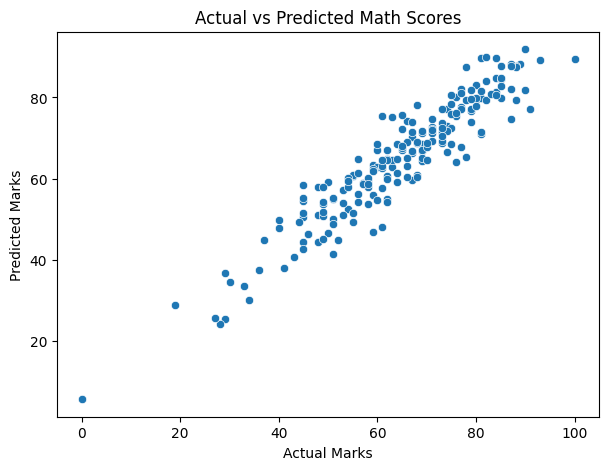

In [ ]:
# Step 10 : Visualization
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Math Scores")
plt.show()

In [ ]:
# Step 11 : Predict Example
print("\n # Example Prediction:\n")
sample_data = X_test.iloc[0:1]
print("Input features:\n", sample_data)
pred = model.predict(sample_data)
print("\n  \n")
print(f"Predicted Math Score: {pred[0]:.2f}")


 # Example Prediction:

Input features:
      gender  race/ethnicity  parental_level_of_education  lunch  \
521       0               2                            0      1   

     test_preparation_course  reading_score  writing_score  
521                        1             86             84  

  

Predicted Math Score: 77.12
